In [1]:
from itertools import product as iproduct

for outcome in iproduct(range(4), repeat=4):
    # prodotto tensoriale M(a1) ⊗ M(a2) ⊗ ... ⊗ M(aN)
    print (outcome, outcome[0], type(outcome))

(0, 0, 0, 0) 0 <class 'tuple'>
(0, 0, 0, 1) 0 <class 'tuple'>
(0, 0, 0, 2) 0 <class 'tuple'>
(0, 0, 0, 3) 0 <class 'tuple'>
(0, 0, 1, 0) 0 <class 'tuple'>
(0, 0, 1, 1) 0 <class 'tuple'>
(0, 0, 1, 2) 0 <class 'tuple'>
(0, 0, 1, 3) 0 <class 'tuple'>
(0, 0, 2, 0) 0 <class 'tuple'>
(0, 0, 2, 1) 0 <class 'tuple'>
(0, 0, 2, 2) 0 <class 'tuple'>
(0, 0, 2, 3) 0 <class 'tuple'>
(0, 0, 3, 0) 0 <class 'tuple'>
(0, 0, 3, 1) 0 <class 'tuple'>
(0, 0, 3, 2) 0 <class 'tuple'>
(0, 0, 3, 3) 0 <class 'tuple'>
(0, 1, 0, 0) 0 <class 'tuple'>
(0, 1, 0, 1) 0 <class 'tuple'>
(0, 1, 0, 2) 0 <class 'tuple'>
(0, 1, 0, 3) 0 <class 'tuple'>
(0, 1, 1, 0) 0 <class 'tuple'>
(0, 1, 1, 1) 0 <class 'tuple'>
(0, 1, 1, 2) 0 <class 'tuple'>
(0, 1, 1, 3) 0 <class 'tuple'>
(0, 1, 2, 0) 0 <class 'tuple'>
(0, 1, 2, 1) 0 <class 'tuple'>
(0, 1, 2, 2) 0 <class 'tuple'>
(0, 1, 2, 3) 0 <class 'tuple'>
(0, 1, 3, 0) 0 <class 'tuple'>
(0, 1, 3, 1) 0 <class 'tuple'>
(0, 1, 3, 2) 0 <class 'tuple'>
(0, 1, 3, 3) 0 <class 'tuple'>
(0, 2, 0

In [4]:
from povm_sampling import *
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix

def create_ghz_state(n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.h(0)
    for i in range(1, n_qubits):
        qc.cx(0, i)
    # qc.measure_all()
    return qc
qc = create_ghz_state(5)
rho = DensityMatrix(qc)
print(rho.data)
# plot_state_city(rho)

prob = povm_probability(rho.data, 5)
print(prob)

[[0.5+0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 ...
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0.5+0.j]]
{(0, 0, 0, 0, 0): 0.015625, (0, 0, 0, 0, 1): 0.005208333333333334, (0, 0, 0, 0, 2): 0.005208333333333334, (0, 0, 0, 0, 3): 0.005208333333333334, (0, 0, 0, 1, 0): 0.005208333333333334, (0, 0, 0, 1, 1): 0.0017361111111111114, (0, 0, 0, 1, 2): 0.0017361111111111114, (0, 0, 0, 1, 3): 0.0017361111111111114, (0, 0, 0, 2, 0): 0.005208333333333334, (0, 0, 0, 2, 1): 0.0017361111111111114, (0, 0, 0, 2, 2): 0.0017361111111111114, (0, 0, 0, 2, 3): 0.0017361111111111114, (0, 0, 0, 3, 0): 0.005208333333333334, (0, 0, 0, 3, 1): 0.0017361111111111114, (0, 0, 0, 3, 2): 0.0017361111111111114, (0, 0, 0, 3, 3): 0.0017361111111111114, (0, 0, 1, 0, 0): 0.005208333333333334, (0,

In [ ]:
samples = sample_povm(prob, 1000000)
p_emp = samples_to_empirical_dist(samples, 5)
print(p_emp)

# test mle

In [3]:
import sys
sys.path.append('../src')

In [5]:
# test of mle
from mle import *
from utils import *
from povm_sampling import *
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere


┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

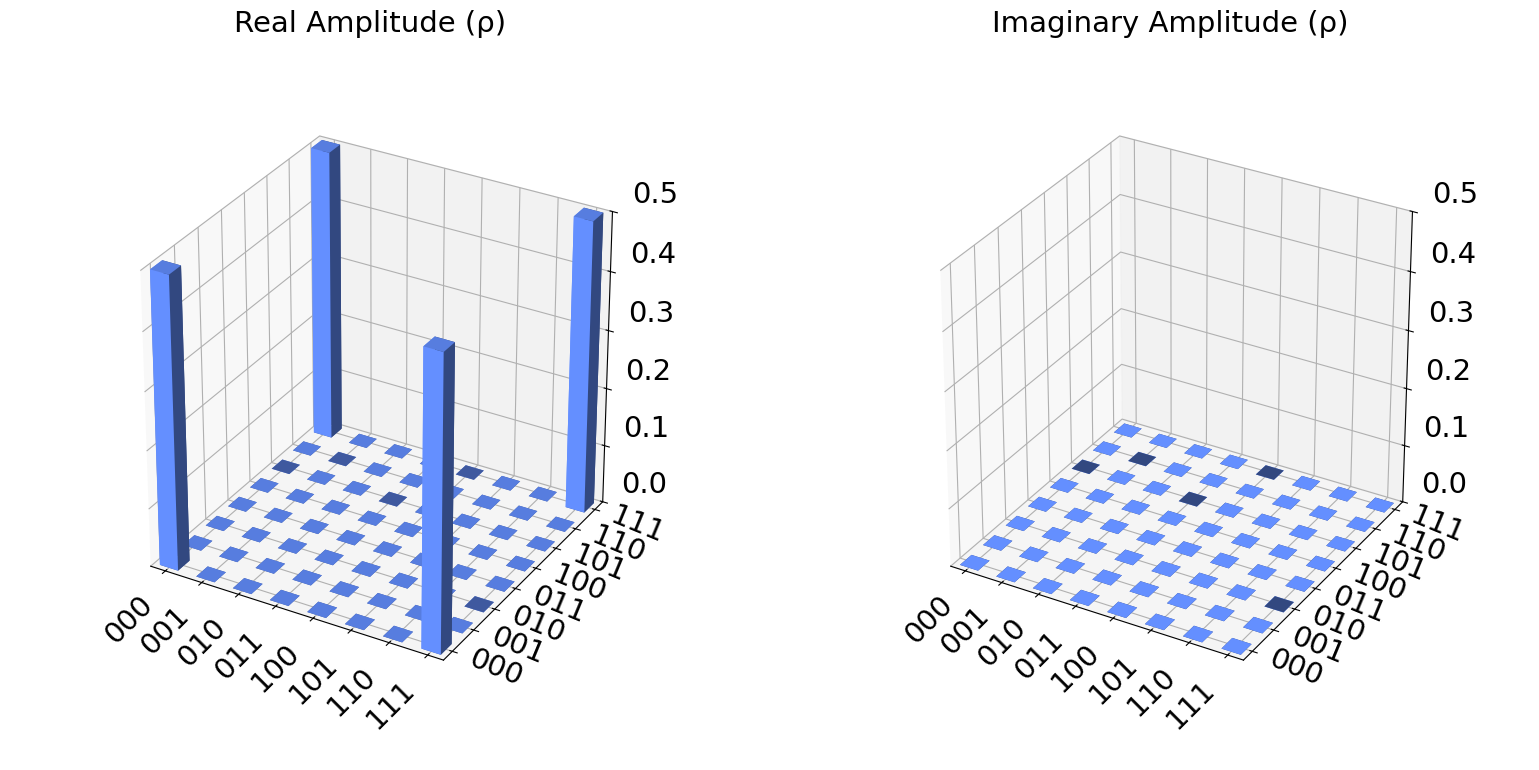

In [7]:
# state simulation
def create_ghz_state(n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.h(0)
    for i in range(1, n_qubits):
        qc.cx(0, i)
    return qc
N = 3
qc = create_ghz_state(N)
display(qc.draw())

rho_true = DensityMatrix(qc)
fig = plot_state_city(rho_true)
display(fig)

In [8]:
# create data
p_exact = povm_probability(rho_true.data, N)
samples = sample_povm(p_exact, 1000)


In [9]:
# minuit
dim = 2**N
init_rho = np.eye(dim, dtype=complex) / dim   # max mixed state
p0 = rho_to_params(init_rho, N)

print(f"Cholesky params: {count_params(N)}  (= (2^N)^2 = {dim**2})")

nll = make_nll(samples, N)

# Minuit
m = Minuit(nll, *p0)
# iminuit built-in to use custom likelihood cost func --> for error estimation m.minos
m.errordef = Minuit.LIKELIHOOD   # = 0.5    
m.print_level = 0

m.migrad()                  
if not m.valid:
    print('not valid!')
    # second try
    m.migrad()              


Cholesky params: 64  (= (2^N)^2 = 64)


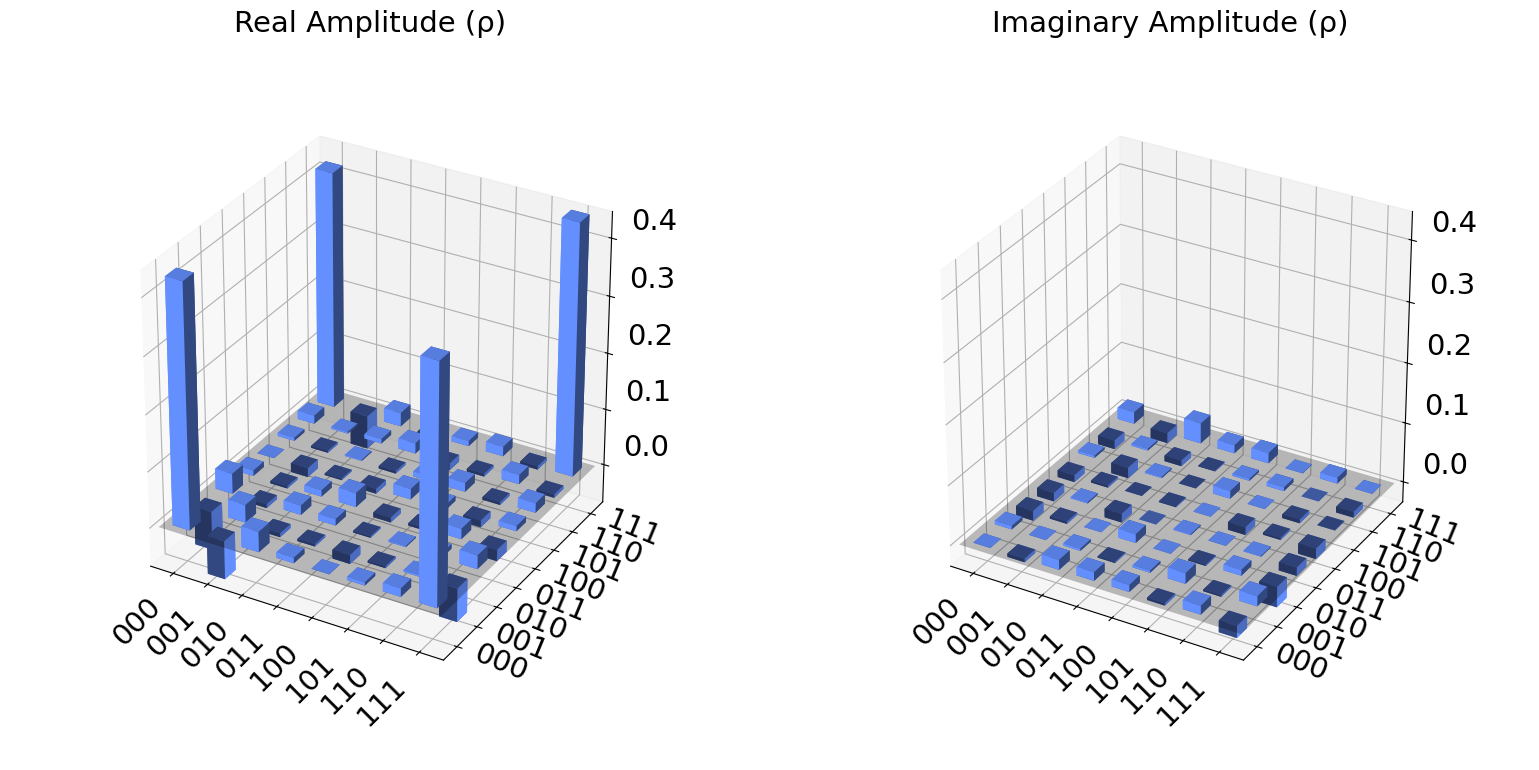

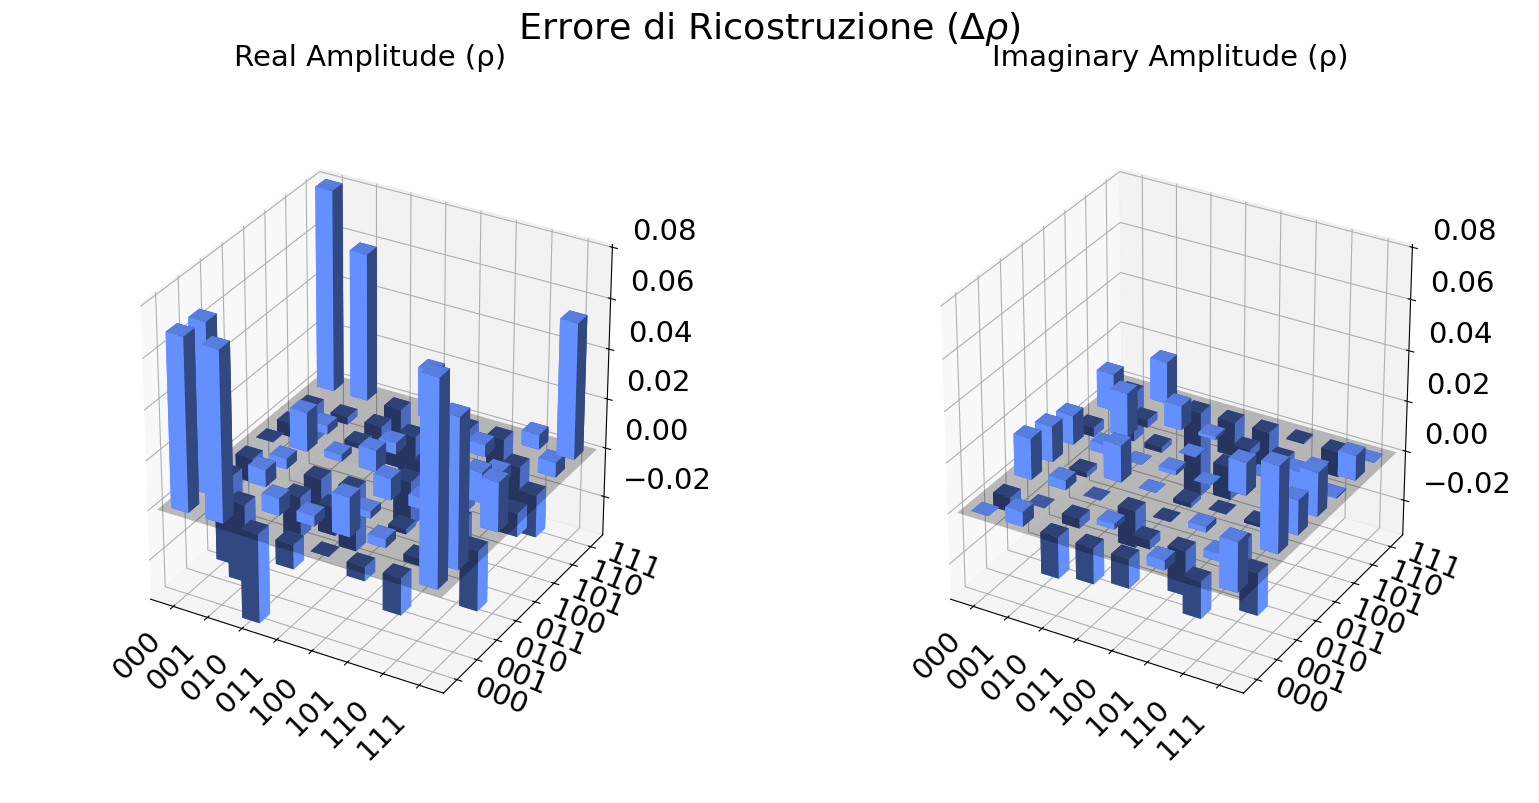

In [10]:
# reconstruct matrix after minimization:
rho_mle = params_to_rho(np.array(m.values), N)
fig = plot_state_city(rho_mle)
display(fig)

# Calcoli la differenza tra le due matrici
rho_diff = rho_true - rho_mle

# Fai il plot: i grattacieli alti indicheranno dove la tua MLE ha sbagliato di più, 
# mentre se le matrici sono identiche vedrai un grafico completamente piatto a zero.
fig = plot_state_city(rho_diff, title="Errore di Ricostruzione ($\\Delta\\rho$)")
display(fig)

In [13]:
print(f"Convergenza Minuit:  {m.valid}\n")
validate_rho(rho_mle);

Convergenza Minuit:  True

  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  True  (min eigval = 2.80e-11)


In [ ]:
# fidelity --> they are from utils.py
fq = quantum_fidelity(rho_true, rho_mle)
print(f"quantum fidelity F_q = {fq:.6f}")

# fidelity classica per confronto
p_sample = samples_to_empirical_dist(samples, N)
fc    = classical_fidelity(p_exact, p_sample)
print(f"classical fidelity (sample)  F_c  = {fc:.6f}")

prob_mle = povm_probability(rho_mle, N)
sample_from_rho_mle = sample_povm(prob_mle, 1000)
p_mle = samples_to_empirical_dist(sample_from_rho_mle, N)
fc    = classical_fidelity(p_exact, p_mle)
print(f"classical fidelity (mle)  F_c  = {fc:.6f}")

quantum fidelity F_q = 0.857054
classical fidelity (sample)  F_c  = 0.988477
classical fidelity (mle)  F_c  = 0.981053


  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  False  (min eigval = -2.19e-01)


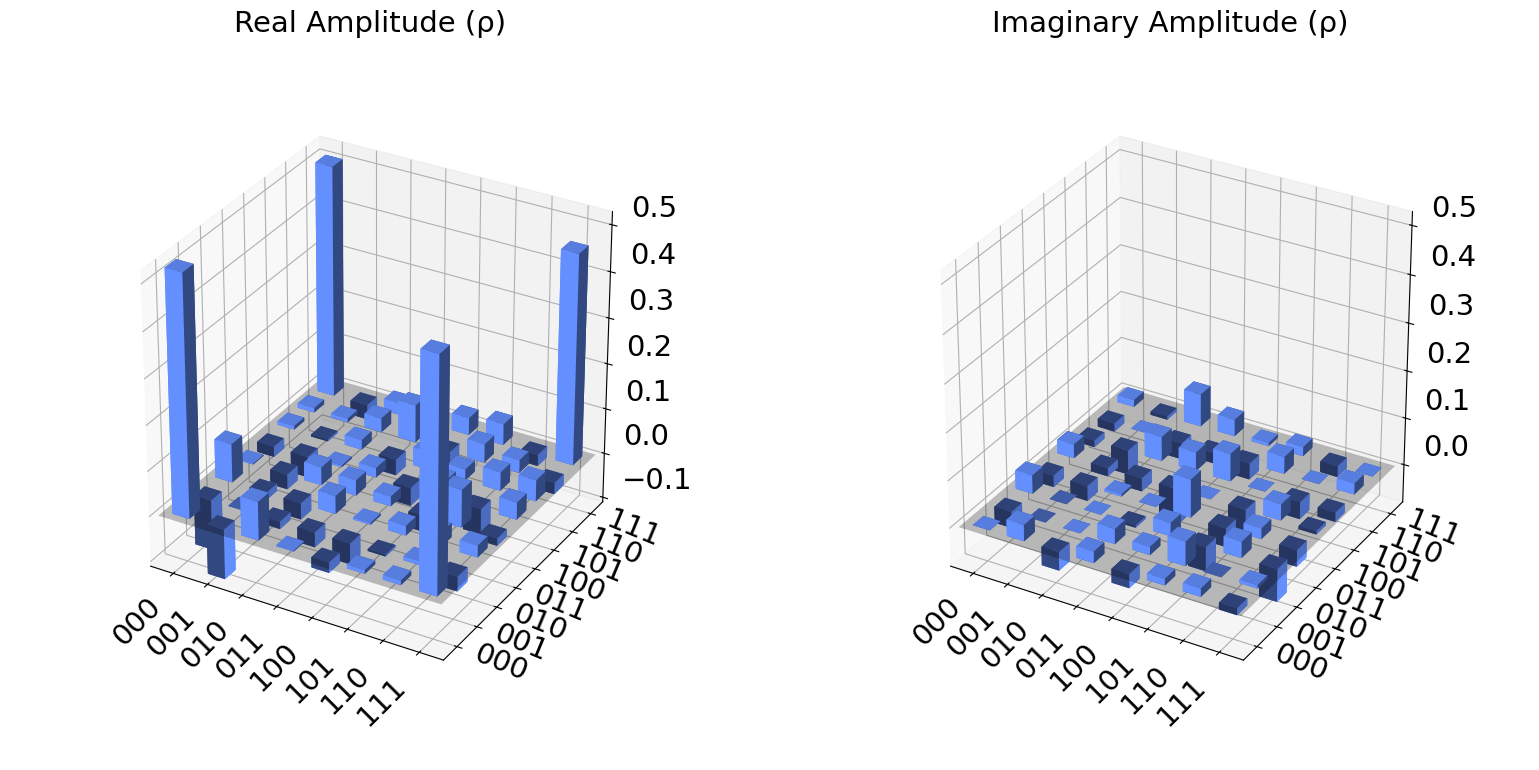

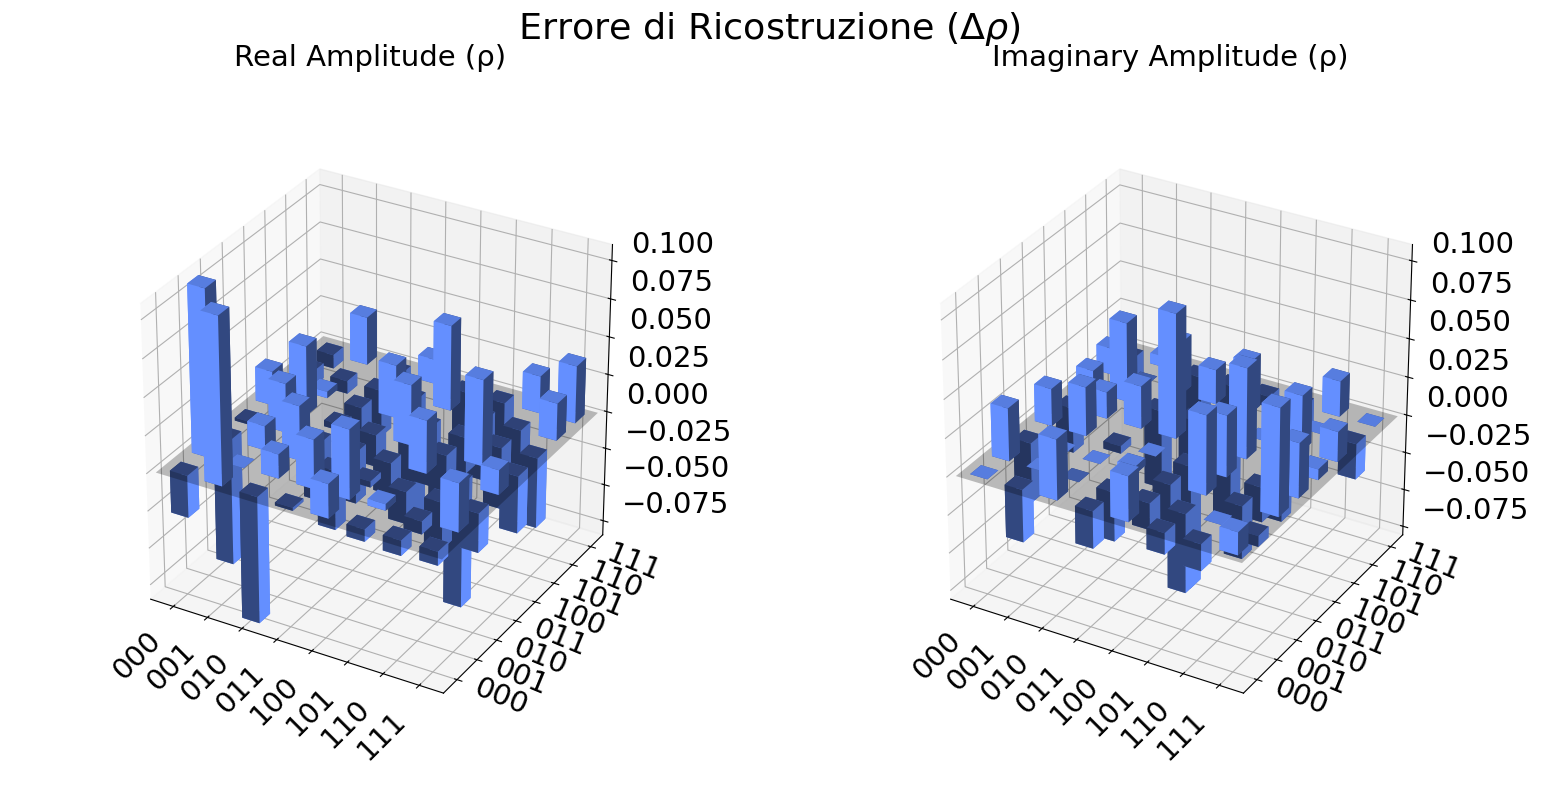

QiskitError: 'Input quantum state is not a valid'

In [ ]:
# reconstruct density matrix direct from p_sample
povm_dict = build_povm(N)
P_vec    = pvec_from_pdict(p_sample, N)
T, T_inv = get_overlap_matrix(N)
rho_sample = reconstruct_rho(P_vec, N, T_inv, povm_dict)

validate_rho(rho_sample)

fig = plot_state_city(rho_sample)
display(fig)

rho_diff = rho_true - rho_sample

fig = plot_state_city(rho_diff, title="Errore di Ricostruzione ($\\Delta\\rho$)")
display(fig)

fq = quantum_fidelity(rho_true, rho_sample)
print(f"quantum fidelity F_q = {fq:.6f}")